Load in Data

In [10]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

path = kagglehub.dataset_download("birdy654/cifake-real-and-ai-generated-synthetic-images")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images


In [11]:
base_path = path  # from your kagglehub output

print(os.listdir(base_path))

['test', 'train']


In [12]:
train_path = os.path.join(base_path, "train")
test_path = os.path.join(base_path, "test")

print("Train folders:", os.listdir(train_path))
print("Test folders:", os.listdir(test_path))

Train folders: ['FAKE', 'REAL']
Test folders: ['FAKE', 'REAL']


Build Dataframe

In [13]:
def load_image_paths(folder, split):
    data = []
    for label in ["REAL", "FAKE"]:
        class_path = os.path.join(folder, label)
        for file in os.listdir(class_path):
            data.append({
                "path": os.path.join(class_path, file),
                "label": label,
                "split": split
            })
    return pd.DataFrame(data)

train_df = load_image_paths(train_path, "train")
test_df = load_image_paths(test_path, "test")

df = pd.concat([train_df, test_df], ignore_index=True)

print(df.head())
print("Total images:", df.shape)

                                                path label  split
0  /kaggle/input/datasets/birdy654/cifake-real-an...  REAL  train
1  /kaggle/input/datasets/birdy654/cifake-real-an...  REAL  train
2  /kaggle/input/datasets/birdy654/cifake-real-an...  REAL  train
3  /kaggle/input/datasets/birdy654/cifake-real-an...  REAL  train
4  /kaggle/input/datasets/birdy654/cifake-real-an...  REAL  train
Total images: (120000, 3)


Class balance

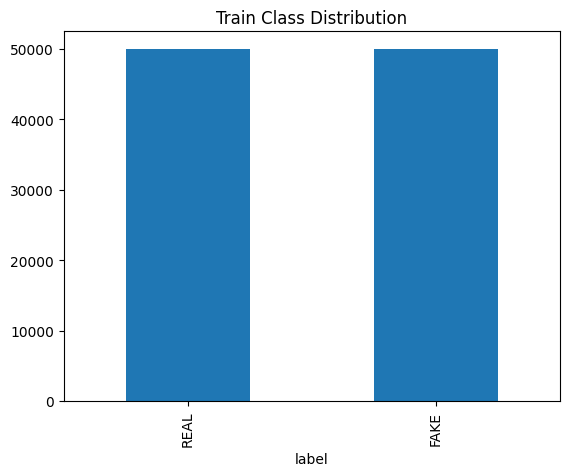

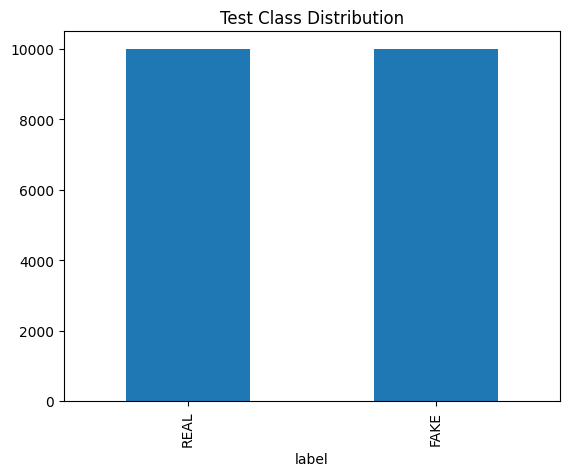

In [14]:
train_df['label'].value_counts().plot(kind='bar')
plt.title("Train Class Distribution")
plt.show()

test_df['label'].value_counts().plot(kind='bar')
plt.title("Test Class Distribution")
plt.show()

This shows that the dataset is balanced across REAL and FAKE classes in the test and train sets. This reduces the risk of class imbalance bias and ensures reliable evaluation metrics.

Sample Images

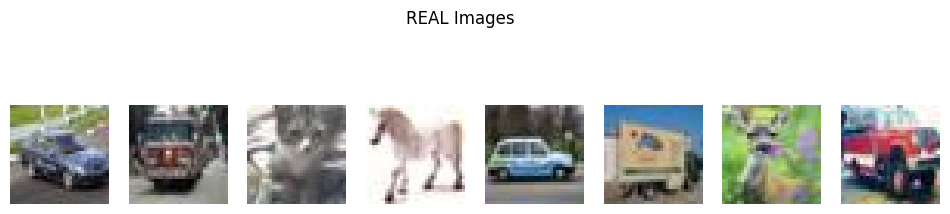

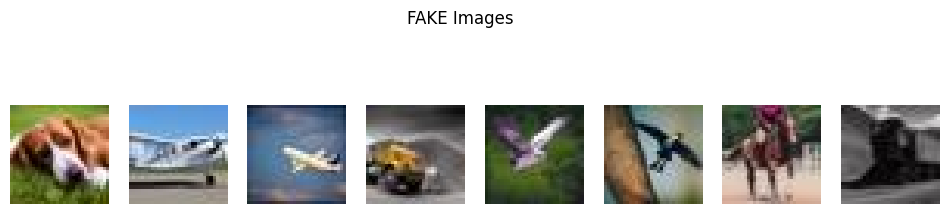

In [15]:
from PIL import Image
import random

def show_images(df, label, n=8):
    subset = df[df['label'] == label].sample(n)
    
    plt.figure(figsize=(12,3))
    for i, row in enumerate(subset.itertuples()):
        img = Image.open(row.path)
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.axis('off')
    
    plt.suptitle(f"{label} Images")
    plt.show()

show_images(df, "REAL")
show_images(df, "FAKE")

This code randomly selects images from the REAL and FAKE classes. The top row shows REAL images and the bottom shows FAKE. We can see here that it is hard to distinguish real images from fake. Thus, using deep learning models to identify images is necessary as the human eye can't accurately differentiate the images. 

Image size check

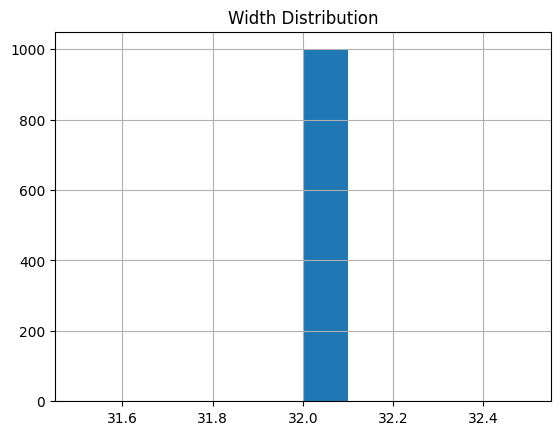

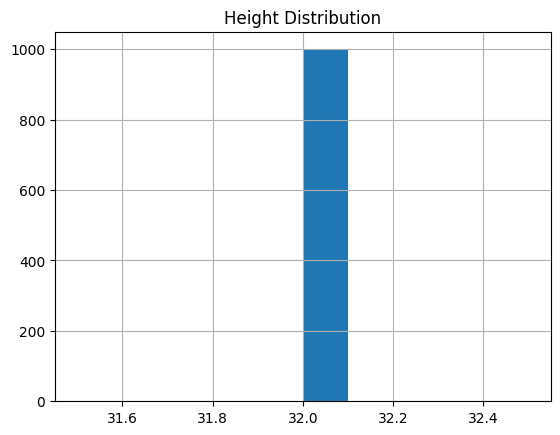

   width  height
0     32      32
1     32      32
2     32      32
3     32      32
4     32      32


In [16]:
sizes = []

for path in df['path'].sample(1000):
    img = Image.open(path)
    sizes.append(img.size)

sizes = pd.DataFrame(sizes, columns=["width", "height"])

sizes['width'].hist()
plt.title("Width Distribution")
plt.show()

sizes['height'].hist()
plt.title("Height Distribution")
plt.show()

print(sizes.head())

These figures confirm that all images are 32x32, this makes the preprocessing process easier but can make classification more difficult due to lower resolution. 

Brightness

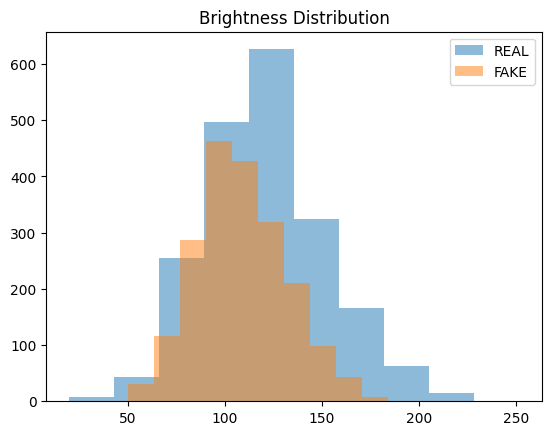

In [17]:
import numpy as np

def get_brightness(df, n=2000):
    vals = []
    sample = df.sample(n)
    
    for path in sample['path']:
        img = np.array(Image.open(path))
        vals.append(img.mean())
    
    return vals

real_brightness = get_brightness(df[df.label=="REAL"])
fake_brightness = get_brightness(df[df.label=="FAKE"])

plt.hist(real_brightness, alpha=0.5, label="REAL")
plt.hist(fake_brightness, alpha=0.5, label="FAKE")
plt.legend()
plt.title("Brightness Distribution")
plt.show()

We see that REAL and FAKE images have similar brightness ranges with strong overlap. REAL images appear to be slightly brighter on average with a wider spread. FAKE images are more concentrated around mid-range values for brightness. 

Pixel Variance

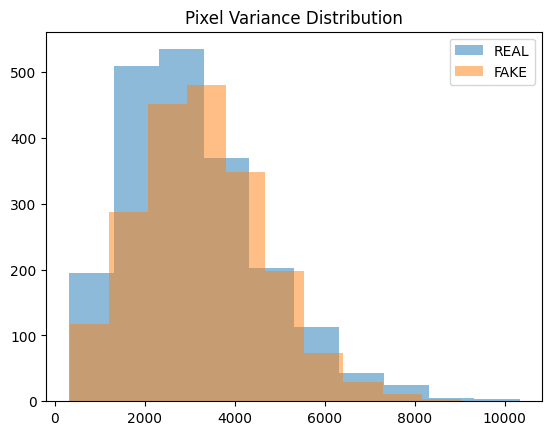

In [18]:
def get_variance(df, n=2000):
    vals = []
    sample = df.sample(n)
    
    for path in sample['path']:
        img = np.array(Image.open(path))
        vals.append(img.var())
    
    return vals

real_var = get_variance(df[df.label=="REAL"])
fake_var = get_variance(df[df.label=="FAKE"])

plt.hist(real_var, alpha=0.5, label="REAL")
plt.hist(fake_var, alpha=0.5, label="FAKE")
plt.legend()
plt.title("Pixel Variance Distribution")
plt.show()

We see that REAL images have slightly higher variance and a wider spread than FAKE. FAKE images are more concentrated for mid-range variance values which indicates more uniform patterns. 